# SVM Model — Full Pipeline

Complete implementation: preprocessing, training, hyperparameter tuning, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt

## 1. Load Data

In [2]:
df = pd.read_csv("data/training_data_202601.csv")
print(f"Shape: {df.shape}")
print(f"Class distribution:\n{df['Painting'].value_counts()}")
df.head()

Shape: (1686, 16)
Class distribution:
Painting
The Persistence of Memory    562
The Starry Night             562
The Water Lily Pond          562
Name: count, dtype: int64


,unique_id,Painting,"On a scale of 1–10, how intense is the emotion conveyed by the artwork?",Describe how this painting makes you feel.,This art piece makes me feel sombre.,This art piece makes me feel content.,This art piece makes me feel calm.,This art piece makes me feel uneasy.,How many prominent colours do you notice in this painting?,How many objects caught your eye in the painting?,How much (in Canadian dollars) would you be willing to pay for this painting?,"If you could purchase this painting, which room would you put that painting in?","If you could view this art in person, who would you want to view it with?",What season does this art piece remind you of?,"If this painting was a food, what would be?",Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.
0,1,The Persistence of Memory,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,The Persistence of Memory,5.0,"The clocks are burnt on a hot desert, it embod...",4 - Agree,3 - Neutral/Unsure,2 - Disagree,1 - Strongly disagree,2.0,4.0,0,Bathroom,By yourself,Fall,Fries,A country song that contrasts nostalgia for th...
2,3,The Persistence of Memory,7.0,This painting makes me feel dread. The clock r...,4 - Agree,1 - Strongly disagree,1 - Strongly disagree,4 - Agree,4.0,3.0,$5,"Bathroom,Dining room","Coworkers/Classmates,By yourself",Fall,Sardines,A melancholy instrumental with a monotone voic...
3,4,The Persistence of Memory,7.0,Deflated,4 - Agree,1 - Strongly disagree,2 - Disagree,4 - Agree,10.0,7.0,a,"Bedroom,Bathroom",Coworkers/Classmates,Winter,a,q
4,5,The Persistence of Memory,7.0,The painting gives me a sense of calmness and ...,3 - Neutral/Unsure,4 - Agree,5 - Strongly agree,3 - Neutral/Unsure,4.0,6.0,300 dollars.,Living room,Friends,"Spring,Summer",Churros.,Radiohead's album in rainbows.


## 2. Grouped Train / Validation / Test Split (70/15/15)

Split by `unique_id` (student) to prevent data leakage — each student answered for all 3 paintings.

In [3]:
unique_ids = df['unique_id'].unique()
rng = np.random.RandomState(42)
rng.shuffle(unique_ids)

n = len(unique_ids)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_ids = set(unique_ids[:n_train])
val_ids = set(unique_ids[n_train:n_train + n_val])
test_ids = set(unique_ids[n_train + n_val:])

df_train = df[df['unique_id'].isin(train_ids)].copy()
df_val = df[df['unique_id'].isin(val_ids)].copy()
df_test = df[df['unique_id'].isin(test_ids)].copy()

print(f"Train: {len(df_train)} rows ({len(train_ids)} students)")
print(f"Val:   {len(df_val)} rows ({len(val_ids)} students)")
print(f"Test:  {len(df_test)} rows ({len(test_ids)} students)")
print(f"\nTrain class balance:\n{df_train['Painting'].value_counts(normalize=True).round(3)}")

Train: 1179 rows (393 students)
Val:   252 rows (84 students)
Test:  255 rows (85 students)

Train class balance:
Painting
The Persistence of Memory    0.333
The Starry Night             0.333
The Water Lily Pond          0.333
Name: proportion, dtype: float64


## 3. Preprocessing

All transformations are fitted on the training set only.

### 3a. Column definitions

In [4]:
target_col = 'Painting'

numeric_cols = [
    'On a scale of 1\u201310, how intense is the emotion conveyed by the artwork?',
    'How many prominent colours do you notice in this painting?',
    'How many objects caught your eye in the painting?',
]

likert_cols = [
    'This art piece makes me feel sombre.',
    'This art piece makes me feel content.',
    'This art piece makes me feel calm.',
    'This art piece makes me feel uneasy.',
]

dollar_col = 'How much (in Canadian dollars) would you be willing to pay for this painting?'

multi_select_cols = [
    'If you could purchase this painting, which room would you put that painting in?',
    'If you could view this art in person, who would you want to view it with?',
    'What season does this art piece remind you of?',
]

text_cols = [
    'Describe how this painting makes you feel.',
    'If this painting was a food, what would be?',
    'Imagine a soundtrack for this painting. Describe that soundtrack without naming any objects in the painting.',
]

### 3b. Likert parsing

In [5]:
def extract_rating(response):
    """'4 - Agree' -> 4"""
    if pd.isna(response):
        return np.nan
    match = re.match(r'^(\d+)', str(response))
    return int(match.group(1)) if match else np.nan

for split_df in [df_train, df_val, df_test]:
    for col in likert_cols:
        split_df[col] = split_df[col].apply(extract_rating)

# Impute with training-set mode
likert_modes = {col: df_train[col].mode()[0] for col in likert_cols}
for split_df in [df_train, df_val, df_test]:
    for col in likert_cols:
        split_df[col] = split_df[col].fillna(likert_modes[col])

print("Likert modes (from train):", likert_modes)

Likert modes (from train): {'This art piece makes me feel sombre.': np.float64(4.0), 'This art piece makes me feel content.': np.float64(4.0), 'This art piece makes me feel calm.': np.float64(4.0), 'This art piece makes me feel uneasy.': np.float64(1.0)}


### 3c. Dollar parsing

In [6]:
def parse_dollar(val):
    """Extract numeric value from messy dollar strings."""
    if pd.isna(val):
        return np.nan
    s = str(val).lower().strip()
    # Remove currency symbols, commas, 'dollars', 'cad', '$'
    s = re.sub(r'[\$,]', '', s)
    s = re.sub(r'(dollars|dollar|cad|cdn|ca|\bca\b)', '', s).strip()
    # Try to extract a number
    match = re.search(r'[\d]+\.?[\d]*', s)
    if match:
        return float(match.group())
    return np.nan

for split_df in [df_train, df_val, df_test]:
    split_df['dollar_parsed'] = split_df[dollar_col].apply(parse_dollar)

# Clip at 1st/99th percentile of training set
p1 = df_train['dollar_parsed'].quantile(0.01)
p99 = df_train['dollar_parsed'].quantile(0.99)
train_dollar_median = df_train['dollar_parsed'].median()

for split_df in [df_train, df_val, df_test]:
    split_df['dollar_parsed'] = split_df['dollar_parsed'].fillna(train_dollar_median)
    split_df['dollar_parsed'] = split_df['dollar_parsed'].clip(p1, p99)
    split_df['dollar_log'] = np.log1p(split_df['dollar_parsed'])

print(f"Dollar: median={train_dollar_median:.1f}, clip=[{p1:.1f}, {p99:.1f}]")

Dollar: median=100.0, clip=[0.0, 966249999.3]


### 3d. Numeric features — outlier clipping & imputation

In [7]:
clip_bounds = {}
numeric_medians = {}
for col in numeric_cols:
    lo = df_train[col].quantile(0.01)
    hi = df_train[col].quantile(0.99)
    clip_bounds[col] = (lo, hi)
    numeric_medians[col] = df_train[col].median()

for split_df in [df_train, df_val, df_test]:
    for col in numeric_cols:
        split_df[col] = split_df[col].fillna(numeric_medians[col])
        lo, hi = clip_bounds[col]
        split_df[col] = split_df[col].clip(lo, hi)

print("Clip bounds:", clip_bounds)

Clip bounds: {'On a scale of 1–10, how intense is the emotion conveyed by the artwork?': (np.float64(1.0), np.float64(10.0)), 'How many prominent colours do you notice in this painting?': (np.float64(1.0), np.float64(14.61999999999989)), 'How many objects caught your eye in the painting?': (np.float64(1.0), np.float64(14.61999999999989))}


### 3e. Standardization (numeric + Likert + dollar)

In [8]:
scaled_cols = numeric_cols + likert_cols + ['dollar_log']

scaler = StandardScaler()
scaler.fit(df_train[scaled_cols])

X_train_scaled = scaler.transform(df_train[scaled_cols])
X_val_scaled = scaler.transform(df_val[scaled_cols])
X_test_scaled = scaler.transform(df_test[scaled_cols])

print(f"Scaled numeric features: {X_train_scaled.shape[1]} columns")

Scaled numeric features: 8 columns


### 3f. Multi-hot encoding

In [10]:
# Build category sets from training data
multi_hot_categories = {}
for col in multi_select_cols:
    categories = set()
    for val in df_train[col].dropna():
        for item in str(val).split(','):
            item = item.strip()
            if item:
                categories.add(item)
    multi_hot_categories[col] = sorted(categories)

for col, cats in multi_hot_categories.items():
    print(f"{col[:40]}... -> {cats}")

def encode_multi_hot(split_df, categories_dict):
    """Encode multi-select columns as binary indicator arrays."""
    arrays = []
    for col, cats in categories_dict.items():
        mat = np.zeros((len(split_df), len(cats)), dtype=np.float64)
        for i, val in enumerate(split_df[col].values):
            if pd.isna(val):
                continue
            selected = {item.strip() for item in str(val).split(',')}
            for j, cat in enumerate(cats):
                if cat in selected:
                    mat[i, j] = 1.0
        arrays.append(mat)
    return np.hstack(arrays)

X_train_mh = encode_multi_hot(df_train, multi_hot_categories)
X_val_mh = encode_multi_hot(df_val, multi_hot_categories)
X_test_mh = encode_multi_hot(df_test, multi_hot_categories)

print(f"Multi-hot features: {X_train_mh.shape[1]} columns")

If you could purchase this painting, whi... -> ['Bathroom', 'Bedroom', 'Dining room', 'Living room', 'Office']
If you could view this art in person, wh... -> ['By yourself', 'Coworkers/Classmates', 'Family members', 'Friends', 'Strangers']
What season does this art piece remind y... -> ['Fall', 'Spring', 'Summer', 'Winter']
Multi-hot features: 14 columns


### 3g. TF-IDF vectorization (3 text columns, 200 features each)

In [17]:
tfidf_vectorizers = {}
X_train_tfidf_parts = []
X_val_tfidf_parts = []
X_test_tfidf_parts = []

for col in text_cols:
    # Fill missing with empty string
    train_text = df_train[col].fillna('').astype(str)
    val_text = df_val[col].fillna('').astype(str)
    test_text = df_test[col].fillna('').astype(str)

    vec = TfidfVectorizer(
        max_features=300,
        sublinear_tf=True,
        stop_words='english',
        min_df=2,
    )
    vec.fit(train_text)
    tfidf_vectorizers[col] = vec

    X_train_tfidf_parts.append(vec.transform(train_text))
    X_val_tfidf_parts.append(vec.transform(val_text))
    X_test_tfidf_parts.append(vec.transform(test_text))

    print(f"  {col[:50]}... -> {vec.transform(train_text).shape[1]} features")

from scipy.sparse import hstack as sp_hstack
X_train_tfidf = sp_hstack(X_train_tfidf_parts)
X_val_tfidf = sp_hstack(X_val_tfidf_parts)
X_test_tfidf = sp_hstack(X_test_tfidf_parts)
print(X_val_tfidf)
print(f"\nTotal TF-IDF features: {X_train_tfidf.shape[1]}")

  Describe how this painting makes you feel.... -> 300 features
  If this painting was a food, what would be?... -> 300 features
  Imagine a soundtrack for this painting. Describe t... -> 300 features
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2405 stored elements and shape (252, 900)>
  Coords	Values
  (0, 25)	0.47105052470512904
  (0, 93)	0.34705620963303285
  (0, 106)	0.3559894494283149
  (0, 174)	0.37986677990192674
  (0, 182)	0.20510310602581286
  (0, 186)	0.43995133509500933
  (0, 221)	0.3084709167238556
  (0, 264)	0.23634162590425853
  (1, 37)	1.0
  (1, 510)	1.0
  (1, 629)	0.5983531982184016
  (1, 755)	0.5542156310788213
  (1, 848)	0.2586155659214016
  (1, 869)	0.5176258045276213
  (2, 92)	1.0
  (2, 848)	1.0
  (3, 5)	0.46608932291449107
  (3, 10)	0.4361730786719313
  (3, 16)	0.4087136884963085
  (3, 92)	0.17061651589460244
  (3, 151)	0.1822415409974297
  (3, 155)	0.41613244496755386
  (3, 213)	0.3468768957725529
  (3, 264)	0.26392260609143614
  (3, 376)	1.0
  

### 3h. Combine all features

In [18]:
X_train = sp_hstack([csr_matrix(X_train_scaled), csr_matrix(X_train_mh), X_train_tfidf])
X_val = sp_hstack([csr_matrix(X_val_scaled), csr_matrix(X_val_mh), X_val_tfidf])
X_test = sp_hstack([csr_matrix(X_test_scaled), csr_matrix(X_test_mh), X_test_tfidf])

y_train = df_train[target_col].values
y_val = df_val[target_col].values
y_test = df_test[target_col].values

print(f"Final feature matrix: {X_train.shape[1]} features")
print(f"  Scaled numeric/Likert/dollar: {X_train_scaled.shape[1]}")
print(f"  Multi-hot categorical:        {X_train_mh.shape[1]}")
print(f"  TF-IDF text:                  {X_train_tfidf.shape[1]}")
print(f"\nX_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

Final feature matrix: 922 features
  Scaled numeric/Likert/dollar: 8
  Multi-hot categorical:        14
  TF-IDF text:                  900

X_train: (1179, 922), X_val: (252, 922), X_test: (255, 922)


## 4. SVM — Hyperparameter Tuning (Grid Search on Validation Set)

We search over:
- **Kernel**: linear, rbf
- **C**: 0.1, 1, 10, 100
- **gamma** (rbf only): scale, auto, 0.1, 0.01

Using One-vs-One (OvO) strategy (`decision_function_shape='ovo'`).

In [20]:
param_grid = [
    # Linear kernel — gamma is irrelevant
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100],
        'decision_function_shape': ['ovo'],
    },
    # RBF kernel — tune gamma as well
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 0.01],
        'decision_function_shape': ['ovo'],
    },
]

# We use a custom CV split that maps exactly to our pre-defined train/val split.
# PredefinedSplit: -1 = training fold, 0 = validation fold.
from sklearn.model_selection import PredefinedSplit

# Combine train + val for GridSearchCV, with a predefined split

from scipy.sparse import vstack as sp_vstack
X_trainval = sp_vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

# -1 for training samples, 0 for validation samples
test_fold = np.concatenate([
    -1 * np.ones(X_train.shape[0], dtype=int),
     0 * np.ones(X_val.shape[0], dtype=int),
])
ps = PredefinedSplit(test_fold)

print(f"Grid search over {sum(len(p.get('C', [1])) * len(p.get('gamma', [1])) * len(p.get('kernel', [1])) for p in param_grid)} configurations")
print(f"Train+Val combined: {X_trainval.shape}")

Grid search over 20 configurations
Train+Val combined: (1431, 922)


In [21]:
%%time

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=ps,
    scoring='accuracy',
    refit=True,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_trainval, y_trainval)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best val accuracy: {grid_search.best_score_:.4f}")

Fitting 1 folds for each of 20 candidates, totalling 20 fits

Best params: {'C': 10, 'decision_function_shape': 'ovo', 'gamma': 'scale', 'kernel': 'rbf'}
Best val accuracy: 0.8849
CPU times: total: 547 ms
Wall time: 9.88 s


In [23]:
# Show all results sorted by rank
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df[['param_kernel', 'param_C', 'param_gamma', 'mean_test_score', 'rank_test_score']]
results_df = results_df.sort_values('rank_test_score')
results_df.head(20)

,param_kernel,param_C,param_gamma,mean_test_score,rank_test_score
12,rbf,10.0,scale,0.884921,1
17,rbf,100.0,auto,0.884921,1
15,rbf,10.0,0.01,0.880952,3
14,rbf,10.0,0.1,0.876984,4
19,rbf,100.0,0.01,0.873016,5
18,rbf,100.0,0.1,0.873016,5
16,rbf,100.0,scale,0.873016,5
0,linear,0.1,NaN,0.873016,5
10,rbf,1.0,0.1,0.869048,9
1,linear,1.0,NaN,0.869048,9


## 5. Evaluate Best Model

In [24]:
best_svm = grid_search.best_estimator_

# Retrain on training set only for clean evaluation
best_params = grid_search.best_params_.copy()
svm_final = SVC(**best_params)
svm_final.fit(X_train, y_train)

y_train_pred = svm_final.predict(X_train)
y_val_pred = svm_final.predict(X_val)
y_test_pred = svm_final.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred, average='macro')
val_f1 = f1_score(y_val, y_val_pred, average='macro')
test_f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"{'Set':<10} {'Accuracy':>10} {'Macro F1':>10}")
print(f"{'—'*30}")
print(f"{'Train':<10} {train_acc:>10.4f} {train_f1:>10.4f}")
print(f"{'Val':<10} {val_acc:>10.4f} {val_f1:>10.4f}")
print(f"{'Test':<10} {test_acc:>10.4f} {test_f1:>10.4f}")

Set          Accuracy   Macro F1
——————————————————————————————
Train          0.9839     0.9839
Val            0.8849     0.8855
Test           0.8706     0.8706


### Classification Report (Validation Set)

In [25]:
print(classification_report(y_val, y_val_pred))

                           precision    recall  f1-score   support

The Persistence of Memory       0.95      0.88      0.91        84
         The Starry Night       0.93      0.82      0.87        84
      The Water Lily Pond       0.80      0.95      0.87        84

                 accuracy                           0.88       252
                macro avg       0.89      0.88      0.89       252
             weighted avg       0.89      0.88      0.89       252



### Classification Report (Test Set)

In [26]:
print(classification_report(y_test, y_test_pred))

                           precision    recall  f1-score   support

The Persistence of Memory       0.91      0.88      0.90        85
         The Starry Night       0.83      0.82      0.83        85
      The Water Lily Pond       0.87      0.91      0.89        85

                 accuracy                           0.87       255
                macro avg       0.87      0.87      0.87       255
             weighted avg       0.87      0.87      0.87       255



### Confusion Matrices

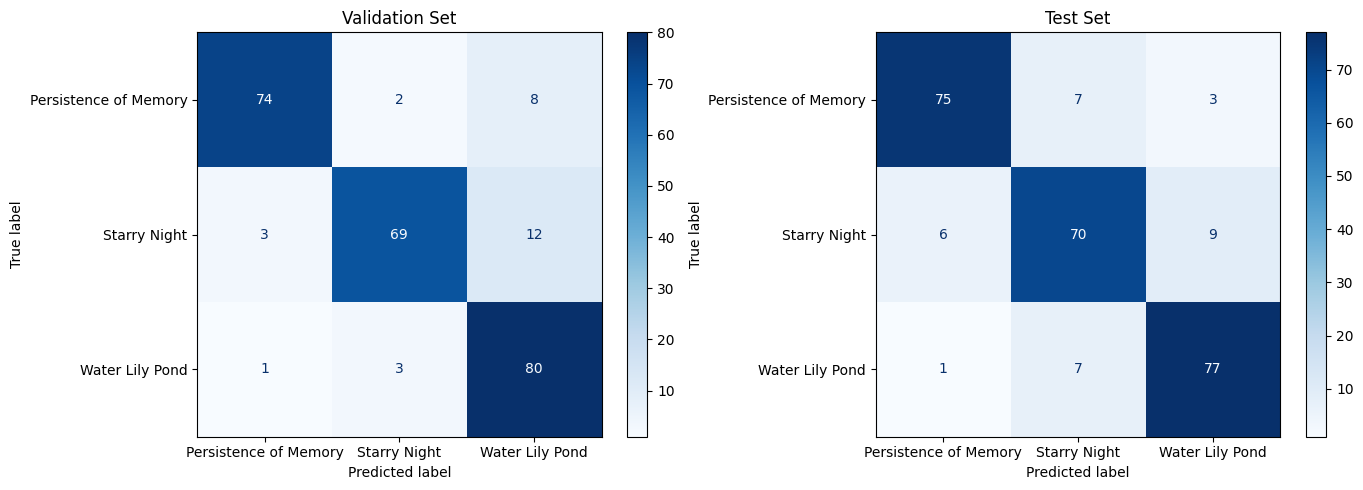

In [27]:
class_names = sorted(df[target_col].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_val, y_val_pred, 'Validation Set'),
    (axes[1], y_test, y_test_pred, 'Test Set'),
]:
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(cm, display_labels=[n.replace('The ', '') for n in class_names])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('figures/svm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Stability Check — Multiple Seeds

In [28]:
# Re-run split + train with different seeds to verify stability
seed_results = []

for seed in [42, 123, 7]:
    rng_s = np.random.RandomState(seed)
    ids_shuffled = unique_ids.copy()
    rng_s.shuffle(ids_shuffled)

    tr_ids = set(ids_shuffled[:n_train])
    va_ids = set(ids_shuffled[n_train:n_train + n_val])
    te_ids = set(ids_shuffled[n_train + n_val:])

    df_tr = df[df['unique_id'].isin(tr_ids)].copy()
    df_va = df[df['unique_id'].isin(va_ids)].copy()
    df_te = df[df['unique_id'].isin(te_ids)].copy()

    # Re-run full preprocessing
    for sdf in [df_tr, df_va, df_te]:
        for col in likert_cols:
            sdf[col] = sdf[col].apply(extract_rating)
    lk_modes = {col: df_tr[col].mode()[0] for col in likert_cols}
    for sdf in [df_tr, df_va, df_te]:
        for col in likert_cols:
            sdf[col] = sdf[col].fillna(lk_modes[col])

    for sdf in [df_tr, df_va, df_te]:
        sdf['dollar_parsed'] = sdf[dollar_col].apply(parse_dollar)
    p1_s = df_tr['dollar_parsed'].quantile(0.01)
    p99_s = df_tr['dollar_parsed'].quantile(0.99)
    med_s = df_tr['dollar_parsed'].median()
    for sdf in [df_tr, df_va, df_te]:
        sdf['dollar_parsed'] = sdf['dollar_parsed'].fillna(med_s).clip(p1_s, p99_s)
        sdf['dollar_log'] = np.log1p(sdf['dollar_parsed'])

    for sdf in [df_tr, df_va, df_te]:
        for col in numeric_cols:
            med_c = df_tr[col].median()
            lo_c = df_tr[col].quantile(0.01)
            hi_c = df_tr[col].quantile(0.99)
            sdf[col] = sdf[col].fillna(med_c).clip(lo_c, hi_c)

    sc = StandardScaler().fit(df_tr[scaled_cols])
    Xtr_s = sc.transform(df_tr[scaled_cols])
    Xva_s = sc.transform(df_va[scaled_cols])
    Xte_s = sc.transform(df_te[scaled_cols])

    Xtr_mh = encode_multi_hot(df_tr, multi_hot_categories)
    Xva_mh = encode_multi_hot(df_va, multi_hot_categories)
    Xte_mh = encode_multi_hot(df_te, multi_hot_categories)

    tfidf_parts_tr, tfidf_parts_va, tfidf_parts_te = [], [], []
    for col in text_cols:
        v = TfidfVectorizer(max_features=200, sublinear_tf=True, stop_words='english', min_df=2)
        v.fit(df_tr[col].fillna('').astype(str))
        tfidf_parts_tr.append(v.transform(df_tr[col].fillna('').astype(str)))
        tfidf_parts_va.append(v.transform(df_va[col].fillna('').astype(str)))
        tfidf_parts_te.append(v.transform(df_te[col].fillna('').astype(str)))

    Xtr = sp_hstack([csr_matrix(Xtr_s), csr_matrix(Xtr_mh)] + tfidf_parts_tr)
    Xva = sp_hstack([csr_matrix(Xva_s), csr_matrix(Xva_mh)] + tfidf_parts_va)
    Xte = sp_hstack([csr_matrix(Xte_s), csr_matrix(Xte_mh)] + tfidf_parts_te)

    svm_s = SVC(**best_params)
    svm_s.fit(Xtr, df_tr[target_col].values)

    va_acc = accuracy_score(df_va[target_col].values, svm_s.predict(Xva))
    te_acc = accuracy_score(df_te[target_col].values, svm_s.predict(Xte))
    seed_results.append({'seed': seed, 'val_acc': va_acc, 'test_acc': te_acc})
    print(f"Seed {seed}: val_acc={va_acc:.4f}, test_acc={te_acc:.4f}")

seed_df = pd.DataFrame(seed_results)
print(f"\nVal  accuracy: mean={seed_df['val_acc'].mean():.4f}, std={seed_df['val_acc'].std():.4f}")
print(f"Test accuracy: mean={seed_df['test_acc'].mean():.4f}, std={seed_df['test_acc'].std():.4f}")

Seed 42: val_acc=0.8929, test_acc=0.9137
Seed 123: val_acc=0.8492, test_acc=0.8980
Seed 7: val_acc=0.8929, test_acc=0.8824

Val  accuracy: mean=0.8783, std=0.0252
Test accuracy: mean=0.8980, std=0.0157


## 7. Hyperparameter Sensitivity Plots

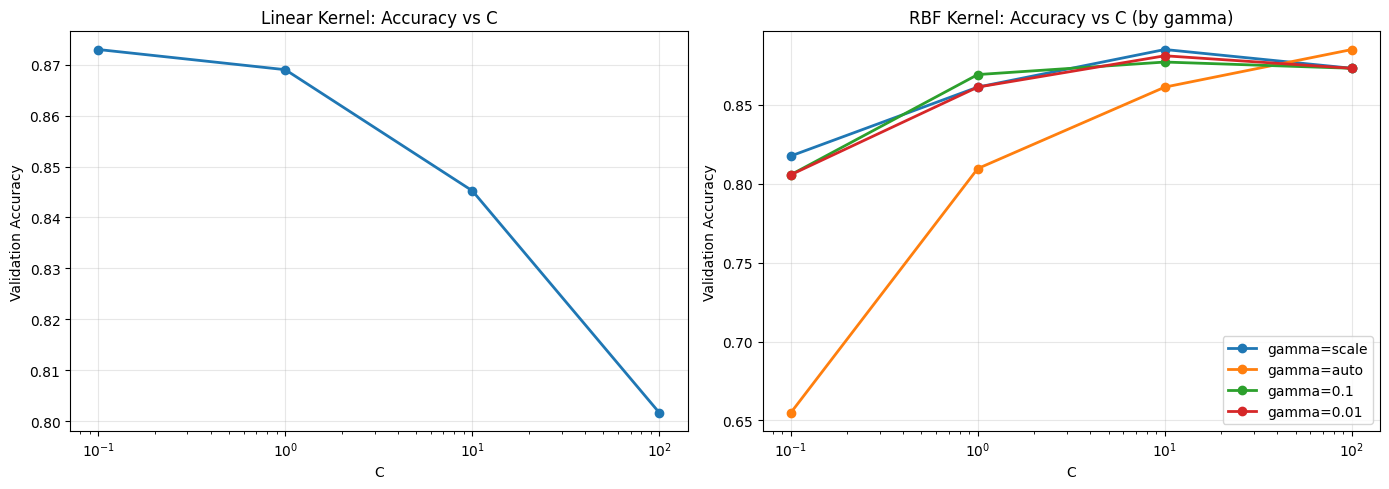

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear kernel: accuracy vs C
linear_results = results_df[results_df['param_kernel'] == 'linear'].copy()
linear_results['param_C'] = linear_results['param_C'].astype(float)
linear_results = linear_results.sort_values('param_C')

axes[0].plot(linear_results['param_C'], linear_results['mean_test_score'], 'o-', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('C')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Linear Kernel: Accuracy vs C')
axes[0].grid(True, alpha=0.3)

# RBF kernel: heatmap of C vs gamma
rbf_results = results_df[results_df['param_kernel'] == 'rbf'].copy()
# Only numeric gamma values for a clean plot
for gamma_val in ['scale', 'auto', 0.1, 0.01]:
    subset = rbf_results[rbf_results['param_gamma'] == gamma_val].copy()
    subset['param_C'] = subset['param_C'].astype(float)
    subset = subset.sort_values('param_C')
    axes[1].plot(subset['param_C'], subset['mean_test_score'], 'o-', label=f'gamma={gamma_val}', linewidth=2)

axes[1].set_xscale('log')
axes[1].set_xlabel('C')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('RBF Kernel: Accuracy vs C (by gamma)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/svm_hyperparam_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

Print final results for the report.

In [30]:
print("=" * 50)
print("SVM FINAL RESULTS")
print("=" * 50)
print(f"Best hyperparameters: {best_params}")
print(f"")
print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print(f"")
print(f"Training Macro F1:   {train_f1:.4f}")
print(f"Validation Macro F1: {val_f1:.4f}")
print(f"Test Macro F1:       {test_f1:.4f}")
print(f"")
print(f"Stability (3 seeds):")
print(f"  Val  accuracy: {seed_df['val_acc'].mean():.4f} ± {seed_df['val_acc'].std():.4f}")
print(f"  Test accuracy: {seed_df['test_acc'].mean():.4f} ± {seed_df['test_acc'].std():.4f}")

SVM FINAL RESULTS
Best hyperparameters: {'C': 10, 'decision_function_shape': 'ovo', 'gamma': 'scale', 'kernel': 'rbf'}

Training Accuracy:   0.9839
Validation Accuracy: 0.8849
Test Accuracy:       0.8706

Training Macro F1:   0.9839
Validation Macro F1: 0.8855
Test Macro F1:       0.8706

Stability (3 seeds):
  Val  accuracy: 0.8783 ± 0.0252
  Test accuracy: 0.8980 ± 0.0157
